In [4]:
import pandas as pd
from pathlib import Path
from getpass import getpass
from urllib.parse import quote_plus
from sqlalchemy import create_engine, text

senha = quote_plus(getpass("Senha do RDS: "))
host = "demand-forecast-db.cbk6cgk8kt1u.us-east-2.rds.amazonaws.com"
engine = create_engine(f"postgresql+psycopg2://postgres:{senha}@{host}:5432/postgres")

with engine.connect() as conn:
    print(conn.execute(text("SELECT COUNT(*) FROM vendas")).scalar(), "linhas na tabela vendas")

Senha do RDS:  ········


36525 linhas na tabela vendas


In [5]:
consultas = {
"resumo_geral.sql": """
SELECT COUNT(*) AS linhas,
       MIN(data) AS primeira_data,
       MAX(data) AS ultima_data,
       COUNT(DISTINCT id_produto) AS produtos,
       COUNT(DISTINCT id_regiao) AS regioes,
       ROUND(SUM(receita), 2) AS receita_total
FROM vendas;
""",
"por_produto.sql": """
SELECT p.nome AS produto,
       SUM(v.quantidade_vendida) AS total_unidades,
       ROUND(SUM(v.receita), 2) AS receita_total
FROM vendas v
JOIN produtos p ON p.id_produto = v.id_produto
GROUP BY p.nome
ORDER BY receita_total DESC;
""",
"por_regiao.sql": """
SELECT r.nome AS regiao,
       SUM(v.quantidade_vendida) AS total_unidades,
       ROUND(SUM(v.receita), 2) AS receita_total
FROM vendas v
JOIN regioes r ON r.id_regiao = v.id_regiao
GROUP BY r.nome
ORDER BY receita_total DESC;
""",
"receita_mensal.sql": """
SELECT DATE_TRUNC('month', data)::date AS mes,
       SUM(quantidade_vendida) AS unidades,
       ROUND(SUM(receita), 2) AS receita
FROM vendas
GROUP BY 1
ORDER BY 1;
""",
"crescimento_mensal.sql": """
WITH mensal AS (
    SELECT DATE_TRUNC('month', data)::date AS mes,
           SUM(receita) AS receita
    FROM vendas
    GROUP BY 1
)
SELECT mes,
       ROUND(receita, 2) AS receita,
       ROUND(LAG(receita) OVER (ORDER BY mes), 2) AS mes_anterior,
       ROUND(100.0 * (receita - LAG(receita) OVER (ORDER BY mes))
             / NULLIF(LAG(receita) OVER (ORDER BY mes), 0), 1) AS variacao_pct
FROM mensal
ORDER BY mes;
""",
"dia_da_semana.sql": """
SELECT EXTRACT(DOW FROM data)::int AS dia_semana,
       ROUND(AVG(unidades_dia), 1) AS media_unidades_por_dia
FROM (
    SELECT data, SUM(quantidade_vendida) AS unidades_dia
    FROM vendas
    GROUP BY data
) t
GROUP BY 1
ORDER BY 1;
""",
}

pasta = Path("../sql")
for nome, sql in consultas.items():
    (pasta / nome).write_text(sql.strip() + "\n")
print("Arquivos criados:", sorted(p.name for p in pasta.glob("*.sql")))

Arquivos criados: ['crescimento_mensal.sql', 'dia_da_semana.sql', 'por_produto.sql', 'por_regiao.sql', 'receita_mensal.sql', 'resumo_geral.sql']


In [6]:
def rodar(arquivo):
    sql = Path(f"../sql/{arquivo}").read_text()
    return pd.read_sql(text(sql), engine)

In [7]:
rodar("resumo_geral.sql")

,linhas,primeira_data,ultima_data,produtos,regioes,receita_total
0,36525,2022-01-01,2025-12-31,5,5,3.415632e+08


In [8]:
rodar("por_produto.sql")

,produto,total_unidades,receita_total
0,Produto_C,541430,88571355.07
1,Produto_D,453810,80007130.38
2,Produto_B,451325,64293889.93
3,Produto_E,487493,57553406.81
4,Produto_A,585385,51137430.50


In [9]:
rodar("por_regiao.sql")

,regiao,total_unidades,receita_total
0,Sudeste,505357,68506262.47
1,Norte,503916,68338836.06
2,Nordeste,503608,68289855.19
3,Sul,503109,68238791.96
4,Centro-Oeste,503453,68189467.01


,mes,unidades,receita
0,2022-01-01,58747,8065828.41
1,2022-02-01,49038,6733647.34
2,2022-03-01,47463,6513077.40
3,2022-04-01,38436,5263752.69
4,2022-05-01,31975,4372160.55


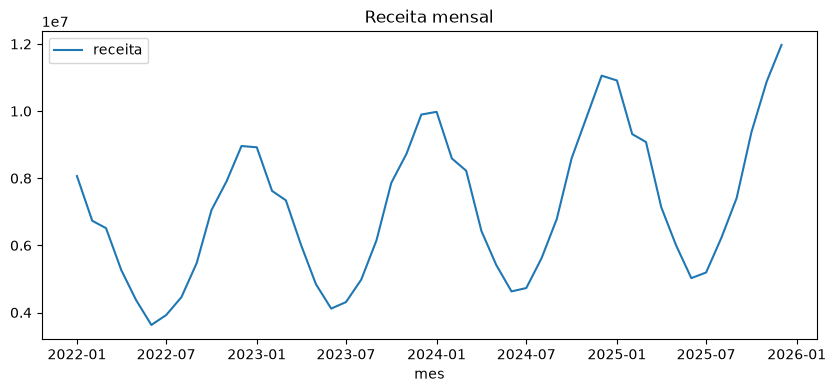

In [10]:
mensal = rodar("receita_mensal.sql")
mensal.plot(x="mes", y="receita", figsize=(10, 4), title="Receita mensal")
mensal.head()

In [11]:
rodar("crescimento_mensal.sql")

,mes,receita,mes_anterior,variacao_pct
0,2022-01-01,8065828.41,NaN,NaN
1,2022-02-01,6733647.34,8065828.41,-16.5
2,2022-03-01,6513077.40,6733647.34,-3.3
3,2022-04-01,5263752.69,6513077.40,-19.2
4,2022-05-01,4372160.55,5263752.69,-16.9
5,2022-06-01,3629954.58,4372160.55,-17.0
6,2022-07-01,3923152.08,3629954.58,8.1
7,2022-08-01,4455774.65,3923152.08,13.6
8,2022-09-01,5472158.75,4455774.65,22.8
9,2022-10-01,7048855.20,5472158.75,28.8


In [12]:
rodar("dia_da_semana.sql")

,dia_semana,media_unidades_por_dia
0,0,2068.0
1,1,1587.4
2,2,1594.3
3,3,1594.5
4,4,1585.3
5,5,1584.0
6,6,2056.4
